## Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import pearsonr, spearmanr, linregress
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

### Load Data

In [2]:
df = pd.read_csv("../data/processed/merged_dataset.csv")

print(df.shape)

df.head()

(100, 1096)


,file_id,filepath,age,sex_x,brain_health_score,total_cognition_score,fluid_cognition_score,crystallized_cognition_score,lhl_1,lhl_2,...,BT2.h.7,SGOT2.h.8,SGPT,Family _History,Medical_History,Barthel_scale,MRS_scale,NIHSS_scale,AHI_1_B,subject_id
0,SN1,sleep_data/SN1.edf,65.0,1,-0.27464,-0.01407,-0.10628,0.08692,0.022346,-0.994057,...,1.14,29.8,25.7,NaN,NaN,100.0,0.0,0.0,50.8,SN1
1,SN2,sleep_data/SN2.edf,60.0,1,-0.36531,0.06125,-0.09295,0.30379,0.152037,-0.997863,...,NaN,30.1,26.8,NaN,NaN,100.0,0.0,0.0,6.5,SN2
2,SN3,sleep_data/SN3.edf,49.0,1,0.24275,0.49118,0.45108,0.23969,0.210161,-0.920484,...,NaN,NaN,NaN,NaN,NaN,100.0,0.0,0.0,41.1,SN3
3,SN4,sleep_data/SN4.edf,47.0,1,0.16931,0.49646,0.48187,0.24427,0.123935,-0.969290,...,0.78,23,25.0,1,NaN,100.0,0.0,0.0,39.1,SN4
4,SN5,sleep_data/SN5.edf,39.0,1,0.00631,0.31138,0.31247,-0.02889,0.179273,-0.829033,...,0.70,30,40.0,NaN,NaN,100.0,0.0,0.0,1.9,SN5


## Required Columns

In [3]:
required_columns = [
    "AHI_1_B",
    "brain_health_score",
    "total_cognition_score",
    "fluid_cognition_score",
    "crystallized_cognition_score"
]

df[required_columns].head()

,AHI_1_B,brain_health_score,total_cognition_score,fluid_cognition_score,crystallized_cognition_score
0,50.8,-0.27464,-0.01407,-0.10628,0.08692
1,6.5,-0.36531,0.06125,-0.09295,0.30379
2,41.1,0.24275,0.49118,0.45108,0.23969
3,39.1,0.16931,0.49646,0.48187,0.24427
4,1.9,0.00631,0.31138,0.31247,-0.02889


## Input and Targets

In [4]:
x = df["AHI_1_B"].values

targets = [
    ("brain_health_score", "Brain Health Score"),
    ("total_cognition_score", "Total Cognition Score"),
    ("fluid_cognition_score", "Fluid Cognition Score"),
    ("crystallized_cognition_score", "Crystallized Cognition Score")
]

In [5]:
df.columns.tolist()

['file_id',
 'filepath',
 'age',
 'sex_x',
 'brain_health_score',
 'total_cognition_score',
 'fluid_cognition_score',
 'crystallized_cognition_score',
 'lhl_1',
 'lhl_2',
 'lhl_3',
 'lhl_4',
 'lhl_5',
 'lhl_6',
 'lhl_7',
 'lhl_8',
 'lhl_9',
 'lhl_10',
 'lhl_11',
 'lhl_12',
 'lhl_13',
 'lhl_14',
 'lhl_15',
 'lhl_16',
 'lhl_17',
 'lhl_18',
 'lhl_19',
 'lhl_20',
 'lhl_21',
 'lhl_22',
 'lhl_23',
 'lhl_24',
 'lhl_25',
 'lhl_26',
 'lhl_27',
 'lhl_28',
 'lhl_29',
 'lhl_30',
 'lhl_31',
 'lhl_32',
 'lhl_33',
 'lhl_34',
 'lhl_35',
 'lhl_36',
 'lhl_37',
 'lhl_38',
 'lhl_39',
 'lhl_40',
 'lhl_41',
 'lhl_42',
 'lhl_43',
 'lhl_44',
 'lhl_45',
 'lhl_46',
 'lhl_47',
 'lhl_48',
 'lhl_49',
 'lhl_50',
 'lhl_51',
 'lhl_52',
 'lhl_53',
 'lhl_54',
 'lhl_55',
 'lhl_56',
 'lhl_57',
 'lhl_58',
 'lhl_59',
 'lhl_60',
 'lhl_61',
 'lhl_62',
 'lhl_63',
 'lhl_64',
 'lhl_65',
 'lhl_66',
 'lhl_67',
 'lhl_68',
 'lhl_69',
 'lhl_70',
 'lhl_71',
 'lhl_72',
 'lhl_73',
 'lhl_74',
 'lhl_75',
 'lhl_76',
 'lhl_77',
 'lhl_78',


## Correlation Analysis

In [6]:
for column, title_name in targets:

    y = df[column].values

    # Pearson Correlation
    pearson_r, pearson_p = pearsonr(x, y)

    # Spearman Correlation
    spearman_rho, spearman_p = spearmanr(x, y)

    print(title_name)
    
    print(f"Pearson r = {pearson_r:.4f}")
    print(f"Pearson p = {pearson_p:.6f}")

    print(f"Spearman rho = {spearman_rho:.4f}")
    print(f"Spearman p   = {spearman_p:.6f}")
    print('\n')


Brain Health Score
Pearson r = -0.1791
Pearson p = 0.074629
Spearman rho = -0.1591
Spearman p   = 0.113839


Total Cognition Score
Pearson r = -0.2364
Pearson p = 0.017870
Spearman rho = -0.2057
Spearman p   = 0.040093


Fluid Cognition Score
Pearson r = -0.2144
Pearson p = 0.032185
Spearman rho = -0.1722
Spearman p   = 0.086620


Crystallized Cognition Score
Pearson r = 0.0223
Pearson p = 0.825459
Spearman rho = 0.0571
Spearman p   = 0.572274




## Ordinary Least Squares (OLS) Regression Analysis

In [7]:
for column, title_name in targets:

    y = df[column].values

    result = linregress(x, y)

    print(title_name)

    print(f"Slope (w)     = {result.slope:.6f}")
    print(f"Intercept (b) = {result.intercept:.6f}")

    print('\n')


Brain Health Score
Slope (w)     = -0.002021
Intercept (b) = 0.035551


Total Cognition Score
Slope (w)     = -0.002800
Intercept (b) = 0.314105


Fluid Cognition Score
Slope (w)     = -0.002991
Intercept (b) = 0.278686


Crystallized Cognition Score
Slope (w)     = 0.000125
Intercept (b) = 0.075978




## Polynomial Regression Analysis

In [8]:
for column, title_name in targets:

    y = df[column].values

    X = x.reshape(-1, 1)

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)

    print(title_name)

    print(f"Weight for x² = {poly_model.coef_[2]:.6f}")
    print(f"Weight for x  = {poly_model.coef_[1]:.6f}")
    print(f"Intercept     = {poly_model.intercept_:.6f}")
    print('\n')

Brain Health Score
Weight for x² = 0.000016
Weight for x  = -0.003004
Intercept     = 0.044417


Total Cognition Score
Weight for x² = 0.000037
Weight for x  = -0.005167
Intercept     = 0.335467


Fluid Cognition Score
Weight for x² = 0.000037
Weight for x  = -0.005308
Intercept     = 0.299594


Crystallized Cognition Score
Weight for x² = -0.000015
Weight for x  = 0.001094
Intercept     = 0.067241




## Create scatter plots

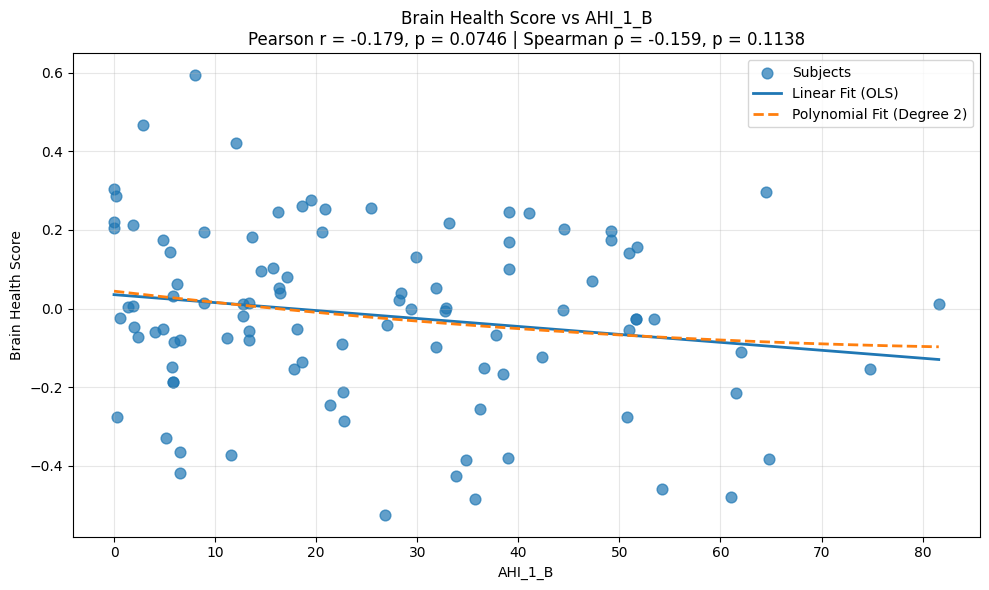

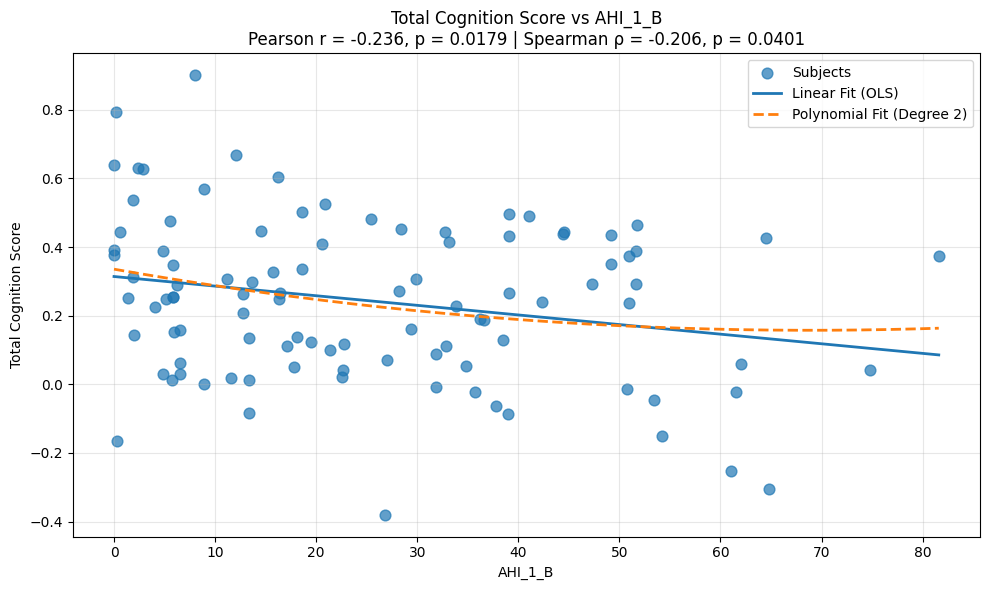

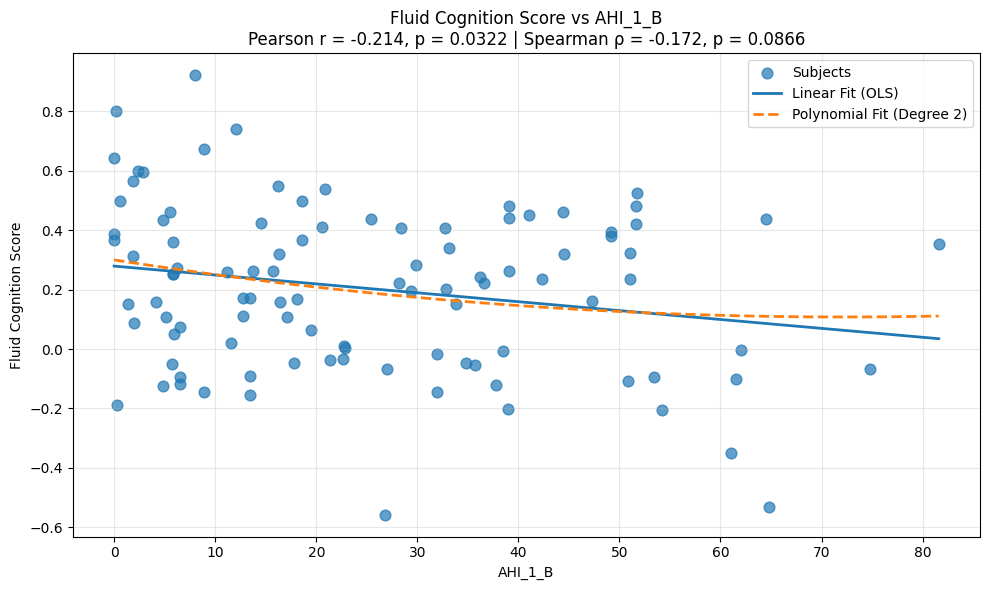

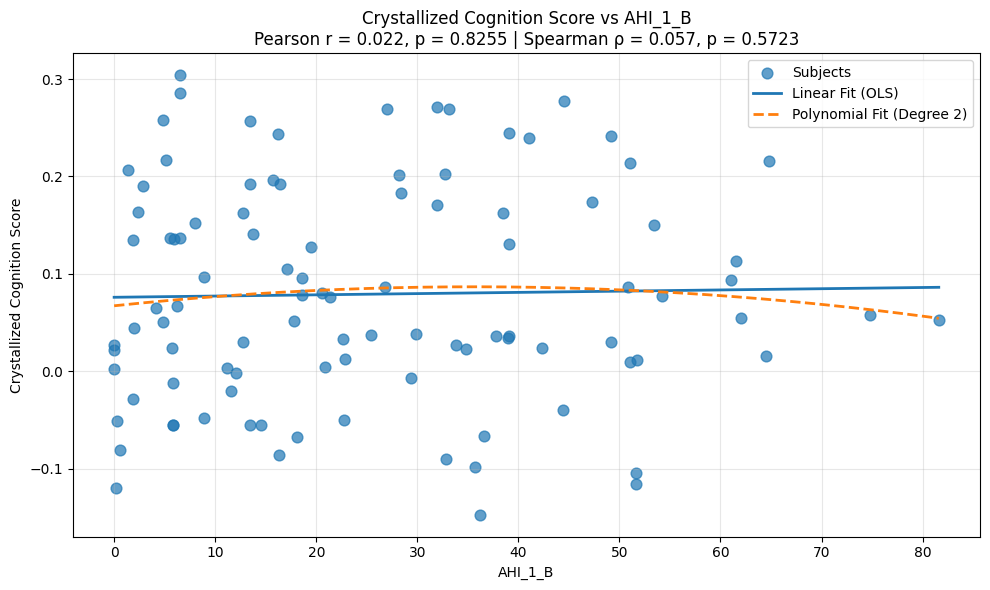

In [9]:
for column, title_name in targets:

    y = df[column].values

    pearson_r, pearson_p = pearsonr(x, y)

    spearman_rho, spearman_p = spearmanr(x, y)

    # OLS Regression
    result = linregress(x, y)

    slope = result.slope
    intercept = result.intercept

    # Polynomial Regression
    X = x.reshape(-1, 1)

    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)

    poly_model = LinearRegression()
    poly_model.fit(X_poly, y)

    # Smooth curve
    x_plot = np.linspace(x.min(), x.max(), 500)

    y_linear = slope * x_plot + intercept

    y_poly = poly_model.predict(
        poly.transform(
            x_plot.reshape(-1, 1)
        )
    )

    # Plot
    plt.figure(figsize=(10, 6))

    plt.scatter(
        x,
        y,
        s=60,
        alpha=0.7,
        label="Subjects"
    )

    plt.plot(
        x_plot,
        y_linear,
        linewidth=2,
        label="Linear Fit (OLS)"
    )

    plt.plot(
        x_plot,
        y_poly,
        "--",
        linewidth=2,
        label="Polynomial Fit (Degree 2)"
    )

    plt.xlabel("AHI_1_B")
    plt.ylabel(title_name)

    plt.title(
        f"{title_name} vs AHI_1_B\n"
        f"Pearson r = {pearson_r:.3f}, p = {pearson_p:.4f} | "
        f"Spearman ρ = {spearman_rho:.3f}, p = {spearman_p:.4f}"
    )

    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.savefig(
        f"../outputs/plots/{column}_analysis.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()